# Satellite Image Classification Model

---

# GPU Being Used:

In [2]:
!nvidia-smi

Fri May  2 21:21:43 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Data Pre-processing:

In [ ]:
!pip install kaggle

In [4]:
!mkdir -p ~/.kaggle

In [7]:
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [12]:
!kaggle datasets download -d mahmoudreda55/satellite-image-classification

Dataset URL: https://www.kaggle.com/datasets/mahmoudreda55/satellite-image-classification
License(s): copyright-authors
satellite-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip satellite-image-classification.zip

In [16]:
import pandas as pd
import os


data = pd.DataFrame(columns=['image_path', 'label'])


labels = {'/content/data/cloudy' : 'Cloudy',
          '/content/data/desert' : 'Desert',
          '/content/data/green_area' : 'Green_Area',
          '/content/data/water' : 'Water',
           }

In [21]:

data_list = []

for folder in labels:
    for image_name in os.listdir(folder):
        image_path = os.path.join(folder, image_name)
        label = labels[folder]
        data_list.append({'image_path': image_path, 'label': label})


data = pd.DataFrame(data_list)

In [22]:

data.to_csv('image_dataset.csv', index=False)

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [25]:

df = pd.read_csv("/content/image_dataset.csv")

In [26]:
df

,image_path,label
0,/content/data/cloudy/train_2841.jpg,Cloudy
1,/content/data/cloudy/train_36004.jpg,Cloudy
2,/content/data/cloudy/train_7387.jpg,Cloudy
3,/content/data/cloudy/train_11820.jpg,Cloudy
4,/content/data/cloudy/train_4003.jpg,Cloudy
...,...,...
5626,/content/data/water/SeaLake_2378.jpg,Water
5627,/content/data/water/SeaLake_602.jpg,Water
5628,/content/data/water/SeaLake_1305.jpg,Water
5629,/content/data/water/SeaLake_2663.jpg,Water


In [27]:

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [28]:

train_datagen = ImageDataGenerator(rescale=1./255,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   rotation_range=45,
                                   vertical_flip=True,
                                   fill_mode='nearest')


test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(dataframe=train_df,
                                                    x_col="image_path",
                                                    y_col="label",
                                                    target_size=(255, 255),
                                                    batch_size=32,
                                                    class_mode="categorical")

test_generator = test_datagen.flow_from_dataframe(dataframe=test_df,
                                                  x_col="image_path",
                                                  y_col="label",
                                                  target_size=(255, 255),
                                                  batch_size=32,
                                                  class_mode="categorical")


Found 4504 validated image filenames belonging to 4 classes.
Found 1127 validated image filenames belonging to 4 classes.


# Deep Learning Model

In [29]:

model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=(255, 255, 3), activation='relu'))
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [40]:
history = model.fit(train_generator, epochs=50, validation_data=test_generator)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 69s 491ms/step - accuracy: 0.8931 - loss: 0.2736 - val_accuracy: 0.9042 - val_loss: 0.2302
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 69s 492ms/step - accuracy: 0.8994 - loss: 0.2476 - val_accuracy: 0.9104 - val_loss: 0.2023
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 71s 501ms/step - accuracy: 0.8934 - loss: 0.2612 - val_accuracy: 0.9122 - val_loss: 0.2185
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 69s 490ms/step - accuracy: 0.9024 - loss: 0.2552 - val_accuracy: 0.8900 - val_loss: 0.3250
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 69s 488ms/step - accuracy: 0.9094 - loss: 0.2619 - val_accuracy: 0.8616 - val_loss: 0.3143
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 82s 488ms/step - accuracy: 0.8870 - loss: 0.2771 - val_accuracy: 0.8988 - val_loss: 0.3105
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 69s 491ms/step - accuracy: 0.8952 - loss: 0.2680 - val_accuracy: 0.9210 - val_loss: 0.2355
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 82s 491ms/step - accuracy: 0.9073 - loss: 0

In [41]:
num_samples = test_df.shape[0]
num_samples

1127

In [34]:
score = model.evaluate(test_generator,
                       steps=num_samples//32+1,
                       )

36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9004 - loss: 0.2422


In [42]:
model.summary

<bound method Model.summary of <Sequential name=sequential, built=True>>

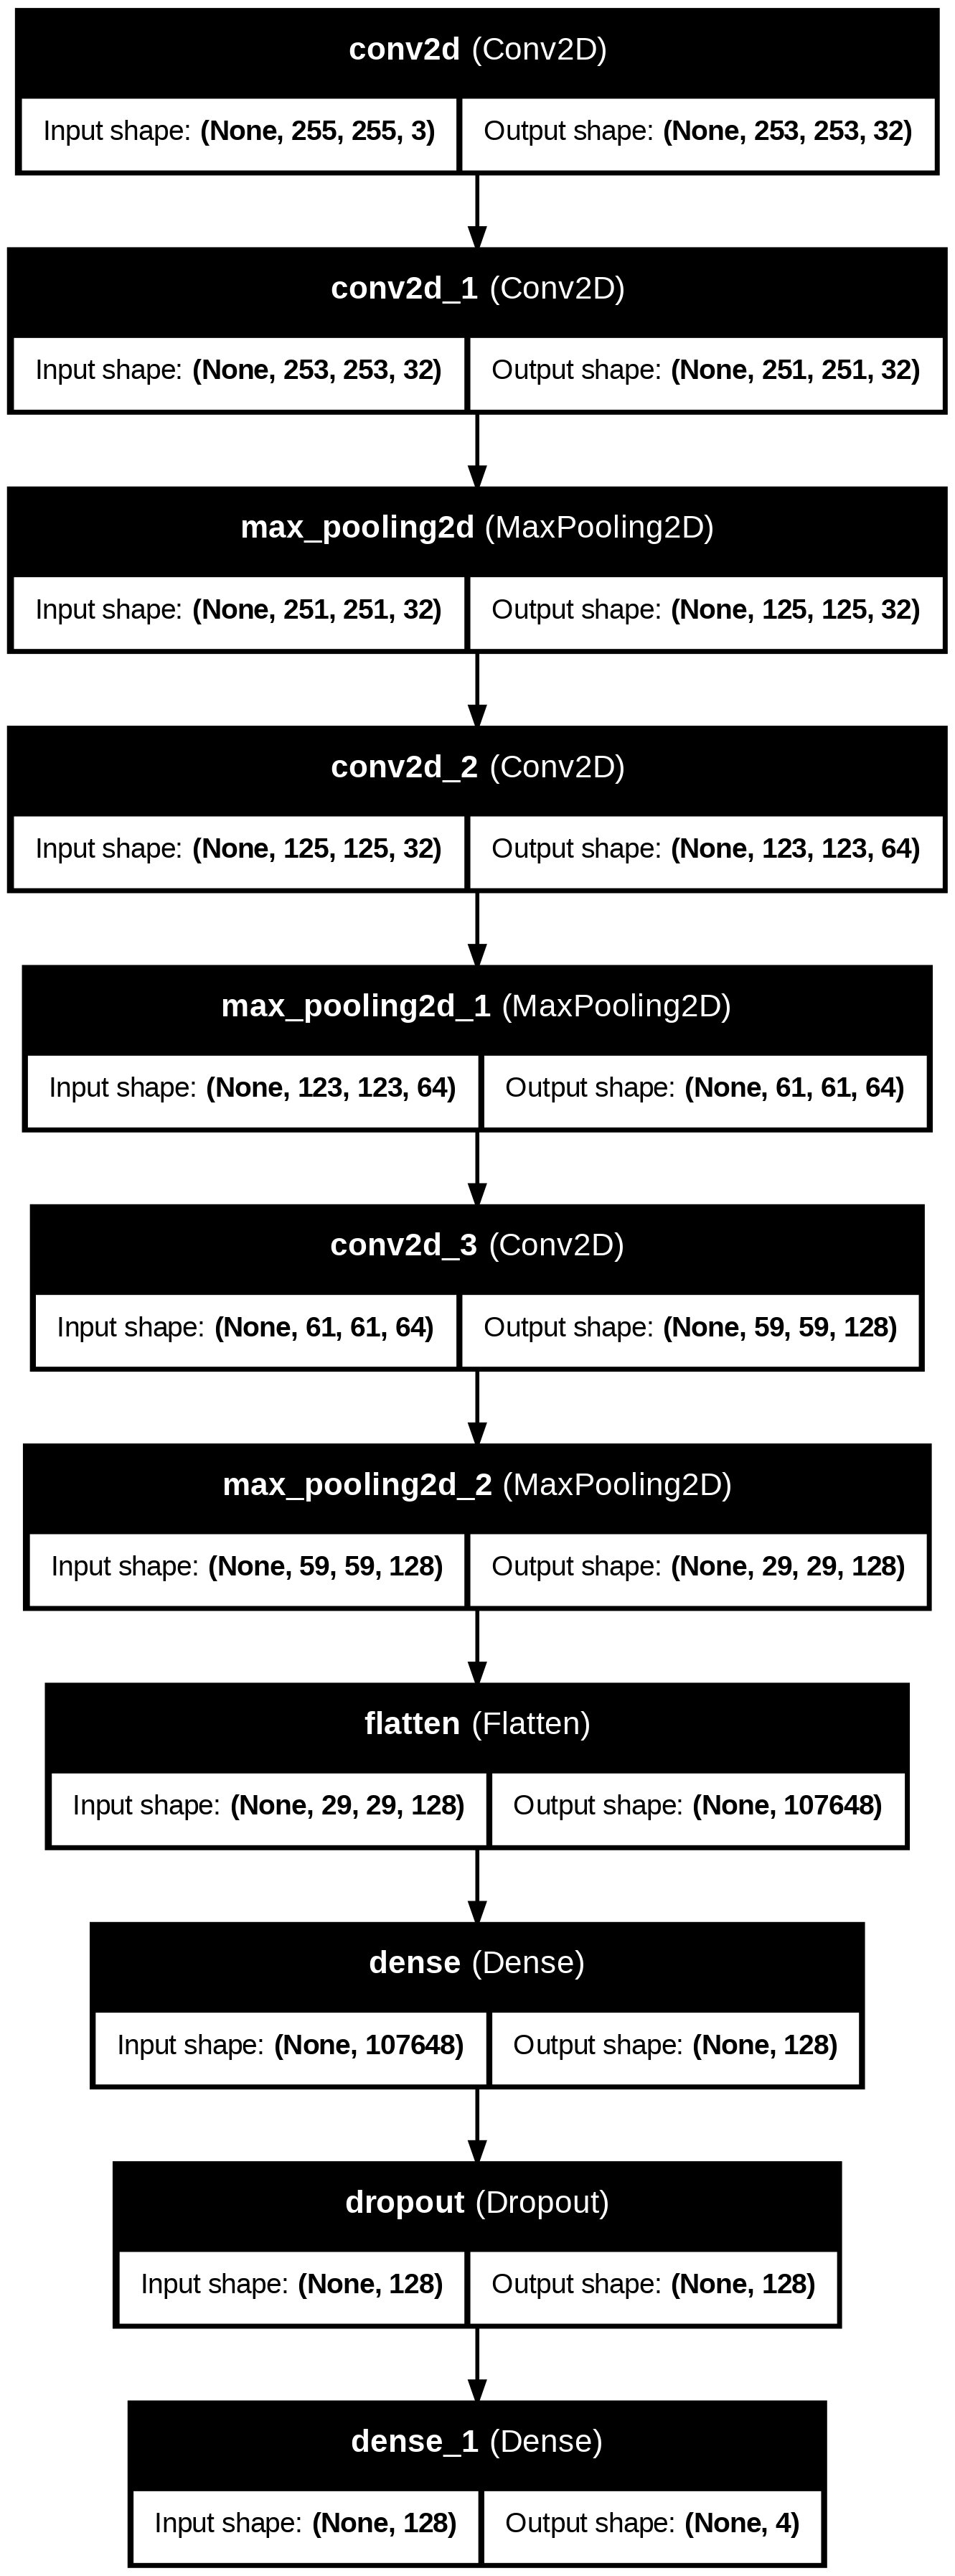

In [43]:
from tensorflow.keras.utils import plot_model
from PIL import Image

plot_model(model, to_file='cnn_model.png', show_shapes=True, show_layer_names=True)
display(Image.open('cnn_model.png'))

# Loss & Accuracy Visualizations

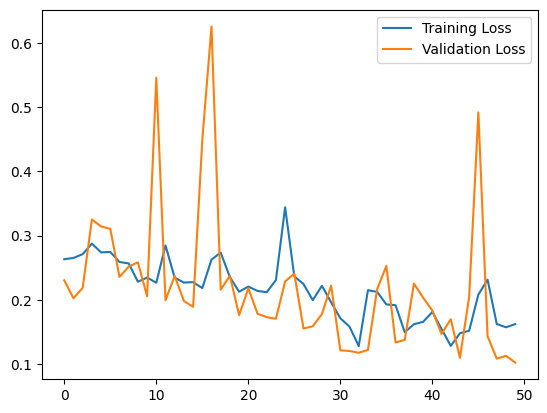

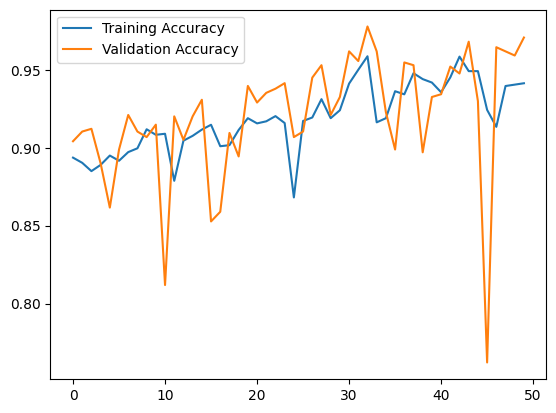

<Figure size 640x480 with 0 Axes>

In [44]:
import matplotlib.pyplot as plt


plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')


plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

# Saving Our Model

In [46]:


from tensorflow.keras.models import load_model

model.save('Model.keras')

In [48]:

model = load_model("Model.keras")

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [49]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array


class_names = ['Cloudy', 'Desert', 'Green_Area', 'Water']

In [50]:

img = load_img("/content/data/cloudy/train_10070.jpg", target_size=(255, 255))

In [51]:

img_array = img_to_array(img)
img_array

array([[[160., 162., 146.],
        [160., 162., 146.],
        [160., 162., 146.],
        ...,
        [158., 160., 143.],
        [158., 160., 143.],
        [158., 160., 143.]],

       [[160., 162., 146.],
        [160., 162., 146.],
        [160., 162., 146.],
        ...,
        [158., 160., 143.],
        [158., 160., 143.],
        [158., 160., 143.]],

       [[160., 162., 146.],
        [160., 162., 146.],
        [160., 162., 146.],
        ...,
        [158., 160., 143.],
        [158., 160., 143.],
        [158., 160., 143.]],

       ...,

       [[161., 163., 147.],
        [162., 163., 148.],
        [163., 163., 149.],
        ...,
        [176., 177., 161.],
        [176., 177., 161.],
        [176., 177., 161.]],

       [[162., 162., 147.],
        [162., 162., 148.],
        [164., 163., 149.],
        ...,
        [175., 177., 162.],
        [175., 177., 162.],
        [175., 177., 162.]],

       [[162., 161., 147.],
        [163., 162., 147.],
        [164., 1

In [52]:
img_array.shape

(255, 255, 3)

In [53]:

img_array = img_array / 255.0
img_array

array([[[0.627451  , 0.63529414, 0.57254905],
        [0.627451  , 0.63529414, 0.57254905],
        [0.627451  , 0.63529414, 0.57254905],
        ...,
        [0.61960787, 0.627451  , 0.56078434],
        [0.61960787, 0.627451  , 0.56078434],
        [0.61960787, 0.627451  , 0.56078434]],

       [[0.627451  , 0.63529414, 0.57254905],
        [0.627451  , 0.63529414, 0.57254905],
        [0.627451  , 0.63529414, 0.57254905],
        ...,
        [0.61960787, 0.627451  , 0.56078434],
        [0.61960787, 0.627451  , 0.56078434],
        [0.61960787, 0.627451  , 0.56078434]],

       [[0.627451  , 0.63529414, 0.57254905],
        [0.627451  , 0.63529414, 0.57254905],
        [0.627451  , 0.63529414, 0.57254905],
        ...,
        [0.61960787, 0.627451  , 0.56078434],
        [0.61960787, 0.627451  , 0.56078434],
        [0.61960787, 0.627451  , 0.56078434]],

       ...,

       [[0.6313726 , 0.6392157 , 0.5764706 ],
        [0.63529414, 0.6392157 , 0.5803922 ],
        [0.6392157 , 0

In [54]:
import numpy as np
img_array = np.reshape(img_array, (1, 255, 255, 3))

# Using Our Model For Predictions

In [55]:

predictions = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 909ms/step


In [56]:

class_index = np.argmax(predictions[0])


predicted_label = class_names[class_index]

print("The image is predicted to be '{}'.".format(predicted_label))

The image is predicted to be 'Cloudy'.


In [57]:
from sklearn.metrics import confusion_matrix
import numpy as np

In [59]:
predictions = model.predict(test_generator)

36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step


In [60]:
predictions

array([[9.99530196e-01, 4.46880498e-04, 9.82175712e-12, 2.28914196e-05],
       [1.15197465e-01, 1.92690823e-06, 3.69338021e-02, 8.47866833e-01],
       [9.97100413e-01, 2.89944559e-03, 2.00833748e-14, 1.39047913e-07],
       ...,
       [9.99030113e-01, 6.92384128e-05, 1.51036783e-09, 9.00638697e-04],
       [7.91703525e-04, 9.99208272e-01, 0.00000000e+00, 1.13802161e-33],
       [1.43809214e-19, 4.32300576e-42, 2.41502273e-14, 1.00000000e+00]],
      dtype=float32)

In [61]:
actual_labels = test_generator.classes

In [62]:
predicted_labels = np.argmax(predictions, axis=1)
predicted_labels

array([0, 3, 0, ..., 0, 1, 3])

In [63]:
cm = confusion_matrix(actual_labels, predicted_labels)

In [64]:
print(cm)

[[99 67 79 83]
 [50 49 74 54]
 [91 56 59 78]
 [90 52 75 71]]


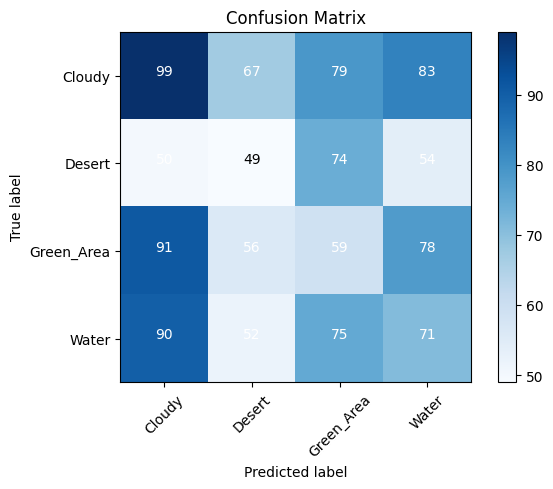

In [65]:
import matplotlib.pyplot as plt
import numpy as np
import itertools





plt.imshow(cm, cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()


tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)


threshold = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j],
             horizontalalignment="center",
             color="white" if cm[i, j] > threshold else "black")

plt.tight_layout()
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

# Advanced Predictions From URLs

In [66]:
from io import BytesIO
import requests
from tensorflow.keras.preprocessing import image
import numpy as np
import tempfile


class_names = ['Cloudy', 'Desert', 'Green_Area', 'Water']

url_list = ['https://eoimages.gsfc.nasa.gov/images/imagerecords/92000/92263/goldstone_oli_2018124_lrg.jpg',
            'https://images.theconversation.com/files/258323/original/file-20190211-174861-jya1so.jpg?ixlib=rb-1.1.0&q=45&auto=format&w=1356&h=668&fit=crop',
            'https://img.freepik.com/free-photo/amazing-beautiful-sky-with-clouds_58702-1657.jpg?w=2000',
            'https://i.natgeofe.com/n/54c007c9-50e5-4cf5-83dc-978a35a4373a/68576_16x9.jpg',
           ]


for url in url_list:
    response = requests.get(url)
    with tempfile.NamedTemporaryFile(mode='wb') as f:
        f.write(response.content)
        f.seek(0)
        img = image.load_img(f.name, target_size=(255, 255))
        img = image.img_to_array(img)
        img = np.expand_dims(img, axis=0)

        classes = model.predict(img, batch_size=10)
        class_index = np.argmax(classes[0])
        predicted_label = class_names[class_index]
        print(url + "The image is predicted to be '{}'.".format(predicted_label))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
https://eoimages.gsfc.nasa.gov/images/imagerecords/92000/92263/goldstone_oli_2018124_lrg.jpgThe image is predicted to be 'Desert'.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
https://images.theconversation.com/files/258323/original/file-20190211-174861-jya1so.jpg?ixlib=rb-1.1.0&q=45&auto=format&w=1356&h=668&fit=cropThe image is predicted to be 'Water'.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
https://img.freepik.com/free-photo/amazing-beautiful-sky-with-clouds_58702-1657.jpg?w=2000The image is predicted to be 'Cloudy'.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
https://i.natgeofe.com/n/54c007c9-50e5-4cf5-83dc-978a35a4373a/68576_16x9.jpgThe image is predicted to be 'Cloudy'.
